In [1]:
#IMPORT PACKAGES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#READ DATA
df = pd.read_csv('salesdaily.csv')
df

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday
1,1/3/2014,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday
2,1/4/2014,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday
3,1/5/2014,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday
4,1/6/2014,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday


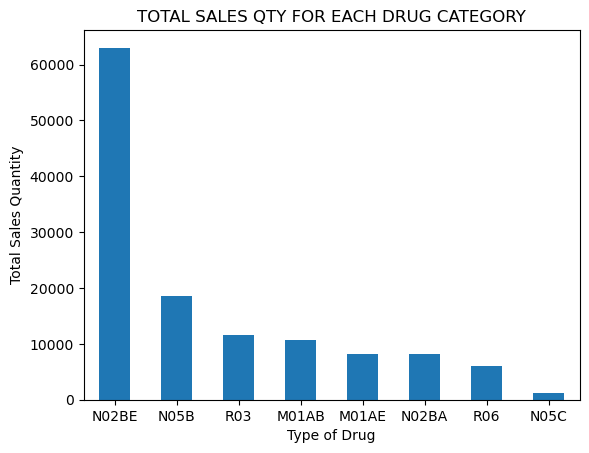

In [3]:
#QN 1: TOTAL SALES QTY FOR EACH DRUG CATEGORY

df_totalsales = df.iloc[:, 1:9]

#TOTAL QUANTITY
drug_sales = df_totalsales.sum().round().astype(int)

#GRAPH
drug_sales.sort_values(ascending=False).plot(kind='bar')

plt.xlabel("Type of Drug")
plt.ylabel("Total Sales Quantity")
plt.title("TOTAL SALES QTY FOR EACH DRUG CATEGORY")
plt.xticks(rotation=360)
plt.show()


In [105]:
#QN 2: INDIVIDUAL DRUG BRANDS WITH HIGHEST TOTAL SALES

top_3sales = drug_sales.nlargest(3)
top_3sales

N02BE    63005
N05B     18646
R03      11609
dtype: int64

In [101]:
#QN 3: 3 DRUGS WITH HIGHEST SALES IN JAN 2015, JUL 2016, SEPT 2017

df_3ysales = df.iloc[:, 1:11] #df with year/month column

def top3_drugs(df, month, year):
    return (
        df[(df['Month'] == month) & (df['Year'] == year)]
        .drop(columns=['Month', 'Year'])
        .sum()
        .nlargest(3)
        .round()
    )

print(top3_drugs(df_3ysales,1,2015))
print(top3_drugs(df_3ysales,7,2016))
print(top3_drugs(df_3ysales,9,2017))

N02BE    1044.0
N05B      463.0
R03       177.0
dtype: float64
N02BE    652.0
N05B     240.0
M01AB    195.0
dtype: float64
N02BE    864.0
N05B     223.0
R03      139.0
dtype: float64


In [104]:
#QN 4: DRUG WITH MOST SALES IN 2017

df_y17 = df_3ysales[df_3ysales['Year'] == 2017]

sales_17 = df_jul16.drop(columns=['Month', 'Year']).sum().round()

top_drug17 = sales_17.nlargest(1)
top_drug17

N02BE    652.0
dtype: float64

In [103]:
#QN 5: DRUG CATEGORY WITH HIGHEST AVG DAILY SALES

avg_daily_sales = df_totalsales.mean().round()
top_drugavg = avg_daily_sales.nlargest(1)
top_drugavg

N02BE    30.0
dtype: float64

In [95]:
#QN 6: R03 DRUGS SOLD MORE IN SPECIFIC MONTHS OR NOT

r03_sales = df.groupby(['Year','Month'])['R06'].mean()

r03_compare = r03_sales.sort_values(ascending = False).unstack()

r03_compare

#Months 4,5,6 tend to have higher sales for R03 


Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2014,1.606667,1.292857,2.754839,2.456667,3.990323,3.643333,2.229032,2.283871,1.960000,1.506048,1.506667,1.077419
2015,1.354839,1.678571,1.741935,3.733333,5.145161,4.193333,4.203226,2.700000,2.366667,2.322581,1.466667,1.346129
2016,1.822581,2.000000,3.156129,5.413333,4.422581,4.493333,3.768710,2.751613,2.310000,1.964516,1.706667,1.125806
2017,1.991935,1.360714,3.229032,4.080000,5.219677,5.063333,2.616129,1.938710,2.230000,1.645161,1.553333,1.519355
2018,1.596774,1.395000,2.758065,6.570000,6.872258,4.026667,3.941935,3.325806,2.936667,2.480645,1.613333,1.712903
2019,1.332258,2.482143,5.467742,5.970000,4.367742,5.201333,3.393548,3.138710,3.636667,1.391250,NaN,NaN
